<a href="https://www.kaggle.com/code/mahabub001cs/batch-vs-stochastic-vs-mini-batch-gradient-descent?scriptVersionId=346015745" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [39]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nani123456789/social-network-ads/Social_Network_Ads.csv


In [40]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [41]:
df = pd.read_csv('/kaggle/input/datasets/nani123456789/social-network-ads/Social_Network_Ads.csv')

In [42]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [43]:
df = df[['Age','EstimatedSalary','Purchased']]

In [44]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [45]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [47]:
X_scaled.shape

(400, 2)

# 1. Batch Gradient Descent

In [48]:
model_batch = Sequential()

model_batch.add(Dense(10, activation = 'relu', input_dim = 2))
model_batch.add(Dense(10, activation = 'relu'))
model_batch.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
model_batch.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
model_batch.compile(loss = 'binary_crossentropy', metrics = ['accuracy'])

history = model_batch.fit(X_scaled, y, epochs = 500, batch_size = len(X_scaled), validation_split = 0.2)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7531 - loss: 0.6500 - val_accuracy: 0.6000 - val_loss: 0.6831
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7688 - loss: 0.6421 - val_accuracy: 0.6000 - val_loss: 0.6778
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7781 - loss: 0.6366 - val_accuracy: 0.6250 - val_loss: 0.6738
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7844 - loss: 0.6322 - val_accuracy: 0.6375 - val_loss: 0.6705
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7844 - loss: 0.6283 - val_accuracy: 0.6500 - val_loss: 0.6676
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7781 - loss: 0.6249 - val_accuracy: 0.6625 - val_loss: 0.6649
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7812 - loss: 0.6216 - val_accuracy: 0.6625 - val_loss: 0.6624
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7875 - loss: 0.6186 - val_accuracy: 0.6625 - val_loss: 0

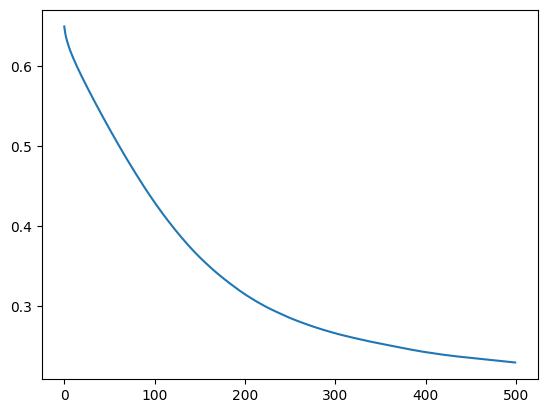

In [51]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.show()

# 2. Stochastic Gradient Descent

In [52]:
model_stochastic = Sequential()

model_stochastic.add(Dense(10, activation = 'relu', input_dim = 2))
model_stochastic.add(Dense(10, activation = 'relu'))
model_stochastic.add(Dense(1, activation = 'sigmoid'))


In [53]:
model_stochastic.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
model_stochastic.compile(loss = 'binary_crossentropy', metrics = ['accuracy'])

start = time.time()
history = model.fit(X_scaled, y, batch_size = 1, epochs = 500, validation_split = 0.2)
print(time.time() - start)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9156 - loss: 0.2847 - val_accuracy: 0.8625 - val_loss: 0.4978
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2769 - val_accuracy: 0.8625 - val_loss: 0.5361
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2800 - val_accuracy: 0.8625 - val_loss: 0.4825
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9156 - loss: 0.2777 - val_accuracy: 0.8625 - val_loss: 0.4694
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2883 - val_accuracy: 0.8625 - val_loss: 0.4488
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2903 - val_accuracy: 0.8625 - val_loss: 0.4506
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2949 - val_accuracy: 0.8625 - val_loss: 0.4832
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2891 - val_accu

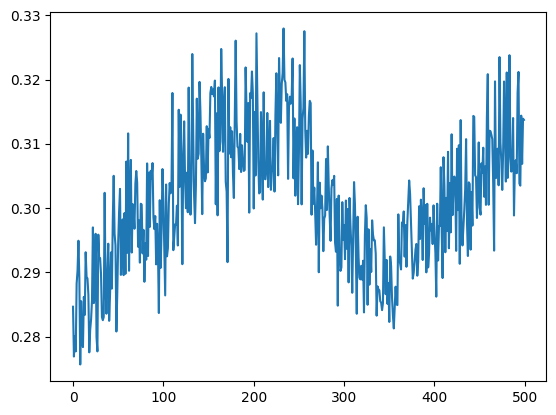

In [55]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.show()

# 3. Mini-Batch Gradient Descent

In [56]:
model_mini_batch = Sequential()

model_mini_batch.add(Dense(10, activation = 'relu', input_dim = 2))
model_mini_batch.add(Dense(10, activation = 'relu'))
model_mini_batch.add(Dense(1, activation = 'sigmoid'))

In [58]:
model_mini_batch.compile(loss = 'binary_crossentropy', metrics = ['accuracy'])

start = time.time()
history = model_mini_batch.fit(X_scaled, y, batch_size = 32, epochs = 500, validation_split = 0.2)
print(time.time() - start)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9094 - loss: 0.2129 - val_accuracy: 0.9375 - val_loss: 0.2359
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9094 - loss: 0.2122 - val_accuracy: 0.9375 - val_loss: 0.2384
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9094 - loss: 0.2118 - val_accuracy: 0.9375 - val_loss: 0.2357
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9094 - loss: 0.2120 - val_accuracy: 0.9375 - val_loss: 0.2368
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9094 - loss: 0.2116 - val_accuracy: 0.9375 - val_loss: 0.2372
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9094 - loss: 0.2118 - val_accuracy: 0.9375 - val_loss: 0.2390
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9094 - loss: 0.2120 - val_accuracy: 0.9375 - val_loss: 0.2365
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9094 - loss: 0.2111 - val_accuracy: 0.9375 - 

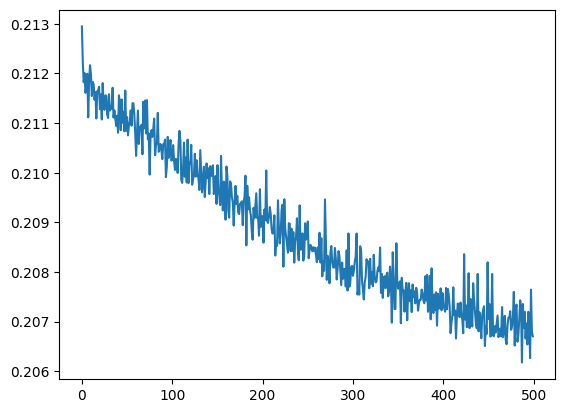

In [59]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.show()